In [ ]:
import pandas as pd

df = pd.read_fwf("/content/public.dat")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/public.dat'

In [ ]:
df.columns

In [ ]:
df = pd.read_fwf("/content/public.dat", header=None)

df.head()

In [ ]:
import os
os.listdir("/content")

In [ ]:
with open("/content/codebook", "r", encoding="latin1") as f:
    print(f.read())

In [ ]:
col_names = [
    "SHEET","CHAIN","CO_OWNED","STATE",
    "SOUTHJ","CENTRALJ","NORTHJ","PA1","PA2","SHORE",
    "NCALLS","EMPFT","EMPPT","NMGRS","WAGE_ST",
    "INCTIME","FIRSTINC","BONUS","PCTAFF","MEALS",
    "OPEN","HRSOPEN","PSODA","PFRY","PENTREE",
    "NREGS","NREGS11",
    "TYPE2","STATUS2","DATE2","NCALLS2",
    "EMPFT2","EMPPT2","NMGRS2","WAGE_ST2",
    "INCTIME2","FIRSTINC2","BONUS2","PCTAFF2",
    "MEALS2","OPEN2","HRSOPEN2","PSODA2",
    "PFRY2","PENTREE2","NREGS2"
]

df.columns = col_names
df.head()

In [ ]:
df.shape

In [ ]:
import pandas as pd

# Wave 1
w1 = df[[
    "SHEET","CHAIN","CO_OWNED","STATE",
    "SOUTHJ","CENTRALJ","NORTHJ","PA1","PA2","SHORE",
    "NCALLS","EMPFT","EMPPT","NMGRS","WAGE_ST",
    "PCTAFF","MEALS","OPEN","HRSOPEN","PSODA","PFRY","PENTREE","NREGS","NREGS11"
]].copy()
w1["wave"] = 1

# Wave 2 (rename to match wave1 names)
w2 = df[[
    "SHEET","CHAIN","CO_OWNED","STATE",
    "SOUTHJ","CENTRALJ","NORTHJ","PA1","PA2","SHORE",
    "NCALLS2","EMPFT2","EMPPT2","NMGRS2","WAGE_ST2",
    "PCTAFF2","MEALS2","OPEN2","HRSOPEN2","PSODA2","PFRY2","PENTREE2","NREGS2"
]].copy()

w2 = w2.rename(columns={
    "NCALLS2":"NCALLS","EMPFT2":"EMPFT","EMPPT2":"EMPPT","NMGRS2":"NMGRS","WAGE_ST2":"WAGE_ST",
    "PCTAFF2":"PCTAFF","MEALS2":"MEALS","OPEN2":"OPEN","HRSOPEN2":"HRSOPEN",
    "PSODA2":"PSODA","PFRY2":"PFRY","PENTREE2":"PENTREE","NREGS2":"NREGS"
})
w2["NREGS11"] = pd.NA
w2["wave"] = 2

# Stack
panel = pd.concat([w1, w2], ignore_index=True)

panel.head(), panel.shape

In [ ]:
panel["treated"] = (panel["STATE"] == 1).astype(int)   # NJ=1
panel["post"] = (panel["wave"] == 2).astype(int)
panel["did"] = panel["treated"] * panel["post"]

panel["emp"] = panel["EMPFT"] + panel["EMPPT"]   # total employment

panel[["SHEET","STATE","wave","treated","post","did","EMPFT","EMPPT","emp"]].head(10)

In [ ]:
import numpy as np
import pandas as pd

for c in ["EMPFT", "EMPPT"]:
    panel[c] = pd.to_numeric(panel[c].replace(".", np.nan), errors="coerce")

panel["emp"] = panel["EMPFT"] + panel["EMPPT"]

panel[["EMPFT","EMPPT","emp"]].head(), panel[["EMPFT","EMPPT","emp"]].dtypes

In [ ]:
mean_table = panel.groupby(["treated","post"])["emp"].mean().unstack()
mean_table

In [ ]:
did_value = (mean_table.loc[1,1] - mean_table.loc[1,0]) - (mean_table.loc[0,1] - mean_table.loc[0,0])
did_value

NameError: name 'mean_table' is not defined

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols("emp ~ treated + post + did", data=panel).fit(cov_type="HC1")
print(model.summary())

In [ ]:
panel.to_csv("njmin_panel_clean.csv", index=False)

In [ ]:
from google.colab import files
files.download("njmin_panel_clean.csv")

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
panel = pd.read_csv("njmin_panel_clean.csv")
panel.head()

In [ ]:
for c in ["EMPFT", "EMPPT", "NMGRS", "WAGE_ST", "PSODA", "PFRY", "PENTREE"]:
    panel[c] = pd.to_numeric(panel[c], errors="coerce")

In [ ]:
panel["fte"] = panel["EMPFT"] + 0.5 * panel["EMPPT"] + panel["NMGRS"]

In [ ]:
panel[["EMPFT","EMPPT","NMGRS","fte"]].head()

In [ ]:
fte_mean_table = panel.groupby(["treated", "post"])["fte"].mean().unstack()
fte_mean_table

In [ ]:
fte_did_value = (fte_mean_table.loc[1, 1] - fte_mean_table.loc[1, 0]) - (fte_mean_table.loc[0, 1] - fte_mean_table.loc[0, 0])
fte_did_value

In [ ]:
table2 = panel.groupby(["STATE", "wave"])[["fte", "WAGE_ST", "PSODA", "PFRY", "PENTREE"]].agg(["mean", "std"])
table2

In [ ]:
import statsmodels.formula.api as smf

model_fte = smf.ols("fte ~ treated + post + did", data=panel).fit(cov_type="HC1")
print(model_fte.summary())

In [ ]:
panel = panel.dropna(subset=["SHEET"])

In [ ]:
panel["SHEET"] = panel["SHEET"].astype(int)

In [ ]:
reg_data = panel[["fte", "treated", "post", "did", "SHEET"]].dropna().copy()

In [ ]:
reg_data["SHEET"] = reg_data["SHEET"].astype(int)

In [ ]:
reg_data.shape

In [ ]:
reg_data.head()

In [ ]:
import statsmodels.formula.api as smf

model_cluster = smf.ols(
    "fte ~ treated + post + did",
    data=reg_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_data["SHEET"]}
)

print(model_cluster.summary())

In [ ]:
cluster_result = pd.DataFrame({
    "coef": model_cluster.params,
    "std_err": model_cluster.bse,
    "p_value": model_cluster.pvalues
})

cluster_result.loc[["treated", "post", "did"]]

In [ ]:
cluster_result.to_csv("did_cluster_results.csv")

In [ ]:
from google.colab import files
files.download("did_cluster_results.csv")

In [ ]:
table2.to_csv("table2_descriptive.csv")

In [ ]:
from google.colab import files
files.download("table2_descriptive.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

panel = pd.read_csv("njmin_panel_clean.csv")
panel.head()

,SHEET,CHAIN,CO_OWNED,STATE,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,PSODA,PFRY,PENTREE,NREGS,NREGS11,wave,treated,post,did,emp
0,46,1,0,0,0,0,0,1,0,0,...,1.03,1.03,0.52,3,3,1,0,0,0,45.0
1,49,2,0,0,0,0,0,1,0,0,...,1.01,0.90,2.35,4,3,1,0,0,0,13.0
2,506,2,1,0,0,0,0,1,0,0,...,0.95,0.74,2.33,3,3,1,0,0,0,10.0
3,56,4,1,0,0,0,0,1,0,0,...,0.87,0.82,1.79,2,2,1,0,0,0,40.0
4,61,4,1,0,0,0,0,1,0,0,...,0.87,0.77,1.65,2,2,1,0,0,0,32.0


In [ ]:
panel["time"] = panel["post"]

In [ ]:
panel["did_post"] = panel["treated"] * panel["post"]

In [ ]:
controls = ["CHAIN", "CO_OWNED", "NREGS"]

In [ ]:
for c in ["EMPFT", "EMPPT", "NMGRS"]:
    panel[c] = pd.to_numeric(panel[c], errors="coerce")

In [ ]:
panel[["EMPFT", "EMPPT", "NMGRS"]].dtypes

,0
EMPFT,float64
EMPPT,float64
NMGRS,float64


In [ ]:
panel["fte"] = panel["EMPFT"] + 0.5 * panel["EMPPT"] + panel["NMGRS"]

In [ ]:
panel[["EMPFT", "EMPPT", "NMGRS", "fte"]].head()

,EMPFT,EMPPT,NMGRS,fte
0,30.0,15.0,3.0,40.50
1,6.5,6.5,4.0,13.75
2,3.0,7.0,2.0,8.50
3,20.0,20.0,4.0,34.00
4,6.0,26.0,5.0,24.00


In [ ]:
model_ext = smf.ols(
    "fte ~ treated + post + did + CHAIN + CO_OWNED + NREGS",
    data=panel
).fit(cov_type="HC1")

print(model_ext.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     57.03
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          3.97e-109
Time:                        16:15:36   Log-Likelihood:                -2880.7
No. Observations:                 794   AIC:                             5791.
Df Residuals:                     779   BIC:                             5862.
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     20.3068      2.851      7.123      0.0

In [ ]:
results_df = pd.DataFrame({
    "variable": model_ext.params.index,
    "estimate": model_ext.params.values,
    "std_error": model_ext.bse.values
})

results_df["ci_lower"] = results_df["estimate"] - 1.96 * results_df["std_error"]
results_df["ci_upper"] = results_df["estimate"] + 1.96 * results_df["std_error"]

results_df

,variable,estimate,std_error,ci_lower,ci_upper
0,Intercept,20.306827,2.850843,14.719175,25.894479
1,NREGS[T.0],-5.287050,2.333127,-9.859978,-0.714122
2,NREGS[T.1],1.348709,2.647248,-3.839897,6.537315
3,NREGS[T.2],5.023280,2.401397,0.316541,9.730018
4,NREGS[T.3],4.087464,2.362935,-0.543888,8.718816
5,NREGS[T.4],4.261003,2.447302,-0.535708,9.057715
6,NREGS[T.5],7.893933,2.523603,2.947670,12.840195
7,NREGS[T.6],7.746726,2.940540,1.983267,13.510185
8,NREGS[T.7],7.614023,3.246739,1.250414,13.977631
9,NREGS[T.8],18.403752,15.864206,-12.690092,49.497597


In [ ]:
plot_df = results_df[results_df["variable"].isin(["treated", "post", "did", "CHAIN", "CO_OWNED"])].copy()
plot_df

,variable,estimate,std_error,ci_lower,ci_upper
10,treated,-3.336268,1.410083,-6.100030,-0.572506
11,post,-1.432276,1.608639,-4.585209,1.720657
12,did,3.095280,1.730042,-0.295603,6.486163
13,CHAIN,-0.423257,0.318724,-1.047956,0.201443
14,CO_OWNED,-2.611193,0.719904,-4.022204,-1.200182


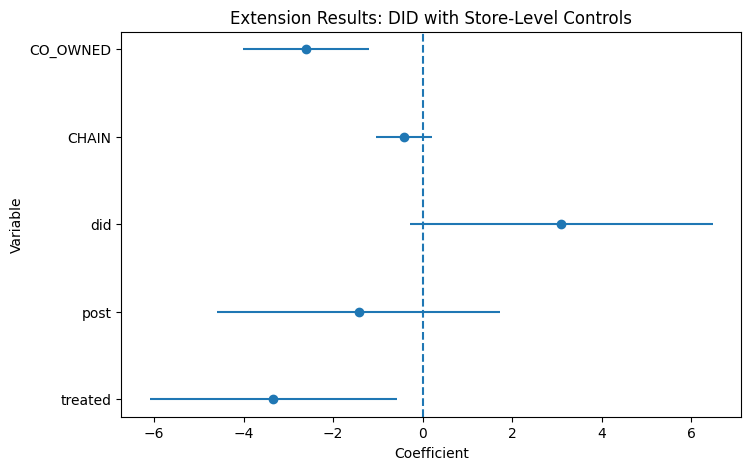

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.errorbar(
    plot_df["estimate"],
    plot_df["variable"],
    xerr=1.96 * plot_df["std_error"],
    fmt="o"
)

plt.axvline(x=0, linestyle="--")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.title("Extension Results: DID with Store-Level Controls")
plt.show()

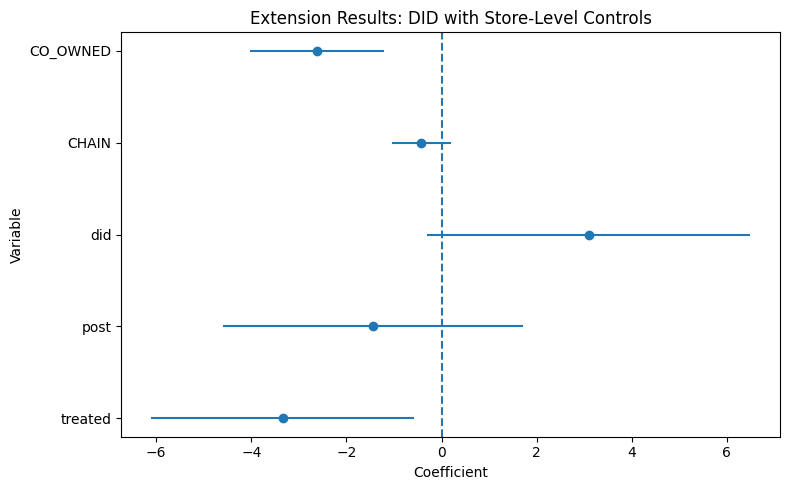

In [ ]:
plt.figure(figsize=(8,5))

plt.errorbar(
    plot_df["estimate"],
    plot_df["variable"],
    xerr=1.96 * plot_df["std_error"],
    fmt="o"
)

plt.axvline(x=0, linestyle="--")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.title("Extension Results: DID with Store-Level Controls")

plt.tight_layout()
plt.savefig("extension_coefficient_plot.png", dpi=300)
plt.show()

In [ ]:
results_df.to_csv("extension_results.csv", index=False)

In [ ]:
from google.colab import files

files.download("extension_results.csv")
files.download("extension_coefficient_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>